# Taller Pacientes


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/pacientes.csv")

df.head()

,edad,colesterol,problema_cardiaco
0,63.0,233.0,1
1,NaN,250.0,0
2,37.0,250.0,0
3,41.0,204.0,0
4,56.0,236.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   edad               300 non-null    float64
 1   colesterol         300 non-null    float64
 2   problema_cardiaco  302 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


In [5]:
df.shape

(302, 3)

In [6]:
df.describe()

,edad,colesterol,problema_cardiaco
count,300.000000,300.000000,302.000000
mean,54.303333,247.280000,0.493377
std,9.090661,51.855681,0.500786
min,29.000000,126.000000,0.000000
25%,47.000000,211.750000,0.000000
50%,55.000000,242.500000,0.000000
75%,61.000000,275.250000,1.000000
max,77.000000,564.000000,1.000000


In [7]:
df.isnull().sum()

,0
edad,2
colesterol,2
problema_cardiaco,0


In [8]:
df[df.isnull().any(axis=1)]

,edad,colesterol,problema_cardiaco
1,NaN,250.0,0
6,NaN,350.0,1
9,44.0,NaN,0
15,64.0,NaN,1


In [9]:
df = df.dropna()
df.isnull().sum()

,0
edad,0
colesterol,0
problema_cardiaco,0


In [10]:
df["problema_cardiaco"].value_counts()

,count
problema_cardiaco,
0,151
1,147


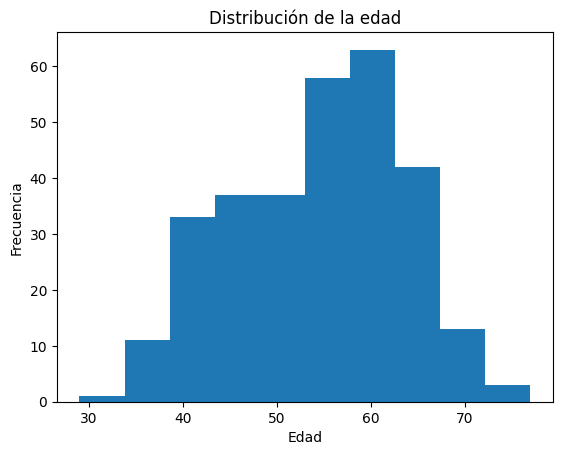

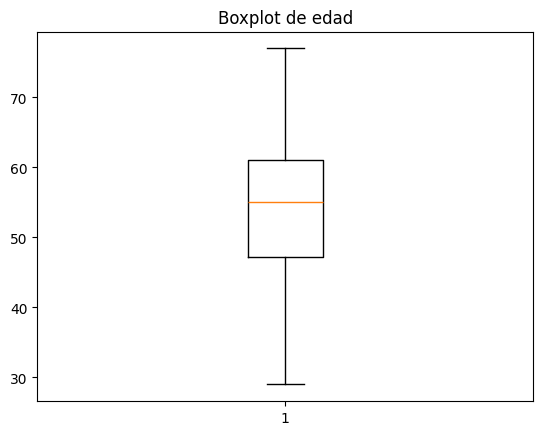

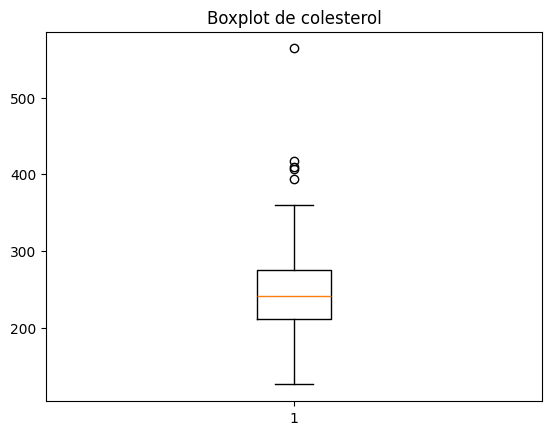

In [11]:
import matplotlib.pyplot as plt

#Gráfico Edad
plt.hist(df["edad"], bins=10)
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

#Valores atípicos de edad
plt.boxplot(df["edad"])
plt.title("Boxplot de edad")
plt.show()

#Valores atípicos colesterol
plt.boxplot(df["colesterol"])
plt.title("Boxplot de colesterol")
plt.show()

In [12]:
print(df["problema_cardiaco"].value_counts(normalize=True) * 100)

problema_cardiaco
0    50.671141
1    49.328859
Name: proportion, dtype: float64


In [13]:
#Renombrar columnas
df = df.rename(columns={
    "edad": "x",
    "colesterol": "y",
    "problema_cardiaco": "label"
})

df.head()

,x,y,label
0,63.0,233.0,1
2,37.0,250.0,0
3,41.0,204.0,0
4,56.0,236.0,1
5,57.0,354.0,1


In [14]:
df["label"] = df["label"].replace({
    0: -1,
    1: 1
})
df["label"].unique()

array([ 1, -1])

In [15]:
#Estandarizar x e y con Z-score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["x", "y"]] = scaler.fit_transform(df[["x", "y"]])
#Requisito: multiplicarlo por 2
df[["x", "y"]] = df[["x", "y"]] * 2

In [16]:
df.head()

,x,y,label
0,1.917452,-0.539783,1
2,-3.816404,0.119142,-1
3,-2.934272,-1.663831,-1
4,0.373722,-0.423502,1
5,0.594255,4.150212,1


In [17]:
df[["x", "y"]].describe()

,x,y
count,2.980000e+02,2.980000e+02
mean,3.814995e-16,-5.126399e-16
std,2.003364e+00,2.003364e+00
min,-5.580667e+00,-4.687133e+00
25%,-1.555941e+00,-1.382819e+00
50%,1.531890e-01,-2.103201e-01
75%,1.476387e+00,1.088150e+00
max,5.004914e+00,1.228987e+01


In [19]:
print("Tamaño final:")
print(df.shape)

print("\nPrimeros registros:")
display(df.head())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores posibles del label:")
print(df["label"].unique())

print("\nMedia de x e y:")
print(df[["x", "y"]].mean())

print("\nDesviación estándar de x e y:")
print(df[["x", "y"]].std())

Tamaño final:
(298, 3)

Primeros registros:


,x,y,label
0,1.917452,-0.539783,1
2,-3.816404,0.119142,-1
3,-2.934272,-1.663831,-1
4,0.373722,-0.423502,1
5,0.594255,4.150212,1



Valores nulos:
x        0
y        0
label    0
dtype: int64

Tipos de datos:
x        float64
y        float64
label      int64
dtype: object

Valores posibles del label:
[ 1 -1]

Media de x e y:
x    3.814995e-16
y   -5.126399e-16
dtype: float64

Desviación estándar de x e y:
x    2.003364
y    2.003364
dtype: float64


In [22]:
#Copia del dataset procesado

ruta_csv_procesado = "/content/drive/MyDrive/CienciaDeDatos/pacientes_preprocesados.csv"

df.to_csv(
    ruta_csv_procesado,
    index=False
)

In [24]:
#Generar el JSON
ruta_json = "/content/drive/MyDrive/CienciaDeDatos/pacientes_preprocesados.json"

df.to_json(
    ruta_json,
    orient="records",
    indent=2
)

In [25]:
with open(ruta_json, "r", encoding="utf-8") as archivo:
    contenido = archivo.read()

print(contenido[:1000])

[
  {
    "x":1.917452471,
    "y":-0.5397825405,
    "label":1
  },
  {
    "x":-3.8164038568,
    "y":0.1191423632,
    "label":-1
  },
  {
    "x":-2.934272114,
    "y":-1.6638309056,
    "label":-1
  },
  {
    "x":0.3737219212,
    "y":-0.4235016752,
    "label":1
  },
  {
    "x":0.5942548569,
    "y":4.150212362,
    "label":1
  },
  {
    "x":0.5942548569,
    "y":-2.128954367,
    "label":1
  },
  {
    "x":0.3737219212,
    "y":1.824595055,
    "label":1
  },
  {
    "x":-0.5084098215,
    "y":-1.8576323478,
    "label":-1
  },
  {
    "x":0.5942548569,
    "y":-3.0592012898,
    "label":-1
  },
  {
    "x":-0.0673439502,
    "y":-0.3072208098,
    "label":1
  },
  {
    "x":-1.3905415643,
    "y":1.0881495744,
    "label":-1
  },
  {
    "x":-1.1700086286,
    "y":0.7393069784,
    "label":-1
  },
  {
    "x":0.8147877926,
    "y":1.398231882,
    "label":-1
  },
  {
    "x":-0.9494756929,
    "y":-1.0824265788,
    "label":-1
  },
  {
    "x":0.8147877926,
    "y":3.6075683

In [26]:
df[["x", "y"]] = df[["x", "y"]].round(4)
df.to_json(
    ruta_json,
    orient="records",
    indent=2
)

In [27]:
with open(ruta_json, "r", encoding="utf-8") as archivo:
    contenido = archivo.read()

print(contenido[:1000])

[
  {
    "x":1.9175,
    "y":-0.5398,
    "label":1
  },
  {
    "x":-3.8164,
    "y":0.1191,
    "label":-1
  },
  {
    "x":-2.9343,
    "y":-1.6638,
    "label":-1
  },
  {
    "x":0.3737,
    "y":-0.4235,
    "label":1
  },
  {
    "x":0.5943,
    "y":4.1502,
    "label":1
  },
  {
    "x":0.5943,
    "y":-2.129,
    "label":1
  },
  {
    "x":0.3737,
    "y":1.8246,
    "label":1
  },
  {
    "x":-0.5084,
    "y":-1.8576,
    "label":-1
  },
  {
    "x":0.5943,
    "y":-3.0592,
    "label":-1
  },
  {
    "x":-0.0673,
    "y":-0.3072,
    "label":1
  },
  {
    "x":-1.3905,
    "y":1.0881,
    "label":-1
  },
  {
    "x":-1.17,
    "y":0.7393,
    "label":-1
  },
  {
    "x":0.8148,
    "y":1.3982,
    "label":-1
  },
  {
    "x":-0.9495,
    "y":-1.0824,
    "label":-1
  },
  {
    "x":0.8148,
    "y":3.6076,
    "label":1
  },
  {
    "x":2.5791,
    "y":-0.8111,
    "label":1
  },
  {
    "x":-2.4932,
    "y":0.0029,
    "label":-1
  },
  {
    "x":3.2407,
    "y":-0.3072,
   

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

# Separar features y target
X = df[["x", "y"]]
y = df["label"]

# División 70/30, como pide el profesor
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

learning_rates = [0.003, 0.01, 0.03, 0.1, 0.3]

arquitecturas = [
    (2,),
    (4,),
    (6,),
    (8,),
    (4, 4),
    (6, 4),
    (8, 4)
]

resultados = []

for arquitectura in arquitecturas:
    for lr in learning_rates:

        modelo = MLPClassifier(
            hidden_layer_sizes=arquitectura,
            activation="relu",
            learning_rate_init=lr,
            max_iter=2000,
            random_state=42
        )

        modelo.fit(X_train, y_train)

        pred_train = modelo.predict(X_train)
        pred_test = modelo.predict(X_test)

        acc_train = accuracy_score(y_train, pred_train)
        acc_test = accuracy_score(y_test, pred_test)

        resultados.append({
            "arquitectura": arquitectura,
            "learning_rate": lr,
            "accuracy_train": acc_train,
            "accuracy_test": acc_test,
            "diferencia": abs(acc_train - acc_test)
        })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by=["accuracy_test", "diferencia"],
    ascending=[False, True]
)

resultados_df.head(10)

,arquitectura,learning_rate,accuracy_train,accuracy_test,diferencia
26,"(6, 4)",0.010,0.807692,0.844444,0.036752
15,"(8,)",0.003,0.798077,0.844444,0.046368
16,"(8,)",0.010,0.788462,0.844444,0.055983
12,"(6,)",0.030,0.812500,0.833333,0.020833
27,"(6, 4)",0.030,0.812500,0.833333,0.020833
30,"(8, 4)",0.003,0.807692,0.833333,0.025641
6,"(4,)",0.010,0.802885,0.833333,0.030449
1,"(2,)",0.010,0.798077,0.833333,0.035256
10,"(6,)",0.003,0.798077,0.833333,0.035256
18,"(8,)",0.100,0.798077,0.833333,0.035256
